# Hybrid Music Recommendation Project
## Notebook 1: Data Exploration and Cleaning

### Objective:
This notebook focuses on:
- Loading the Spotify dataset
- Performing exploratory data analysis (EDA)
- Identifying feature groups
- Cleaning the data
- Preparing it for modeling


Import Libraries

In [1]:
import pandas as pd
import numpy as np



Load the Dataset
View shape and first few rows

In [2]:
df = pd.read_csv('data.csv')


In [3]:
print("Dataset shape:", df.shape)
df.head()           
df.columns          


Dataset shape: (169907, 19)


Index(['id', 'name', 'artists', 'duration_ms', 'release_date', 'year',
       'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'mode',
       'key', 'popularity', 'explicit'],
      dtype='object')

Initial Data Exploration

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169907 entries, 0 to 169906
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                169907 non-null  object 
 1   name              169907 non-null  object 
 2   artists           169907 non-null  object 
 3   duration_ms       169907 non-null  int64  
 4   release_date      169907 non-null  object 
 5   year              169907 non-null  int64  
 6   acousticness      169907 non-null  float64
 7   danceability      169907 non-null  float64
 8   energy            169907 non-null  float64
 9   instrumentalness  169907 non-null  float64
 10  liveness          169907 non-null  float64
 11  loudness          169907 non-null  float64
 12  speechiness       169907 non-null  float64
 13  tempo             169907 non-null  float64
 14  valence           169907 non-null  float64
 15  mode              169907 non-null  int64  
 16  key               16

,duration_ms,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
count,1.699070e+05,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000,169907.000000
mean,2.314071e+05,1977.223234,0.493217,0.538147,0.488591,0.161939,0.206692,-11.370311,0.094058,116.947850,0.532091,0.708552,5.200498,31.556681,0.084864
std,1.213223e+05,25.593318,0.376628,0.175345,0.267391,0.309330,0.176797,5.666795,0.149938,30.727079,0.262407,0.454431,3.515272,21.582730,0.278680
min,5.108000e+03,1921.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.710400e+05,1957.000000,0.094500,0.417000,0.263000,0.000000,0.098400,-14.470000,0.034900,93.516000,0.322000,0.000000,2.000000,12.000000,0.000000
50%,2.086000e+05,1978.000000,0.492000,0.548000,0.481000,0.000204,0.135000,-10.474000,0.045000,114.777000,0.544000,1.000000,5.000000,33.000000,0.000000
75%,2.629665e+05,1999.000000,0.888000,0.667000,0.710000,0.086800,0.263000,-7.118000,0.075400,135.712000,0.749000,1.000000,8.000000,48.000000,0.000000
max,5.403500e+06,2020.000000,0.996000,0.988000,1.000000,1.000000,1.000000,3.855000,0.969000,244.091000,1.000000,1.000000,11.000000,100.000000,1.000000


Checking for Missing Values & Duplicates

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df.isnull().sum().sort_values(ascending=False)    

Duplicate rows: 0


id                  0
liveness            0
popularity          0
key                 0
mode                0
valence             0
tempo               0
speechiness         0
loudness            0
instrumentalness    0
name                0
energy              0
danceability        0
acousticness        0
year                0
release_date        0
duration_ms         0
artists             0
explicit            0
dtype: int64

## Feature Group Identification

Based on the dataset, we can categorize the features into the following groups:

### Audio Features
These are numerical attributes that describe the sonic qualities of a track:
- `acousticness`
- `danceability`
- `energy`
- `instrumentalness`
- `liveness`
- `loudness`
- `speechiness`
- `tempo`
- `valence`

### Metadata Features
These describe the track’s context:
- `release_date`

###  User Behavior Proxy
These simulate user engagement:
- `popularity`

# Data Cleaning

We remove duplicate records, rows with missing critical information, and clean up the release_date column to ensure consistency. Future dates are also removed.

Selection deleted

In [15]:
df.drop_duplicates(inplace=True)
df.dropna(subset=['release_date', 'popularity'], inplace=True)


df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

df.dropna(subset=['release_date'], inplace=True)
df['release_year'] = df['release_date'].dt.year

In [18]:
df.shape

(93185, 20)

In [20]:
df[['name', 'release_date']].sample(5)

,name,release_date
138548,The Drapery Falls,2001-02-27
147752,Tootsee Roll,1994-05-27
111544,Quero Esquecer Você,2063-01-01
116605,Run,2015-03-17
13817,Beat on the Brat - 2016 Remaster,1976-04-23


# Normalize Audio Features

## Install Required Libraries

We install the ⁠ scikit-learn ⁠ package to use MinMaxScaler for feature scaling.

In [9]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:

from sklearn.preprocessing import MinMaxScaler

audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']


df = df[df['popularity'] > 30]


if df[audio_features].shape[0] > 0:
    scaler = MinMaxScaler()
    df[audio_features] = scaler.fit_transform(df[audio_features])
    print("Scaling successful")
else:
    print("No rows to scale — your dataframe is empty. Try adjusting the filter.")

Scaling successful


##  Feature Scaling with MinMaxScaler

After filtering out low-popularity songs, audio features are scaled to a range between 0 and 1 for consistency and modeling.

In [11]:
from sklearn.preprocessing import MinMaxScaler

audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

scaler = MinMaxScaler()
df[audio_features] = scaler.fit_transform(df[audio_features])

## Outlier Detection

Boxplots help us visually inspect for extreme values in each audio feature, which might distort the analysis or scaling results.

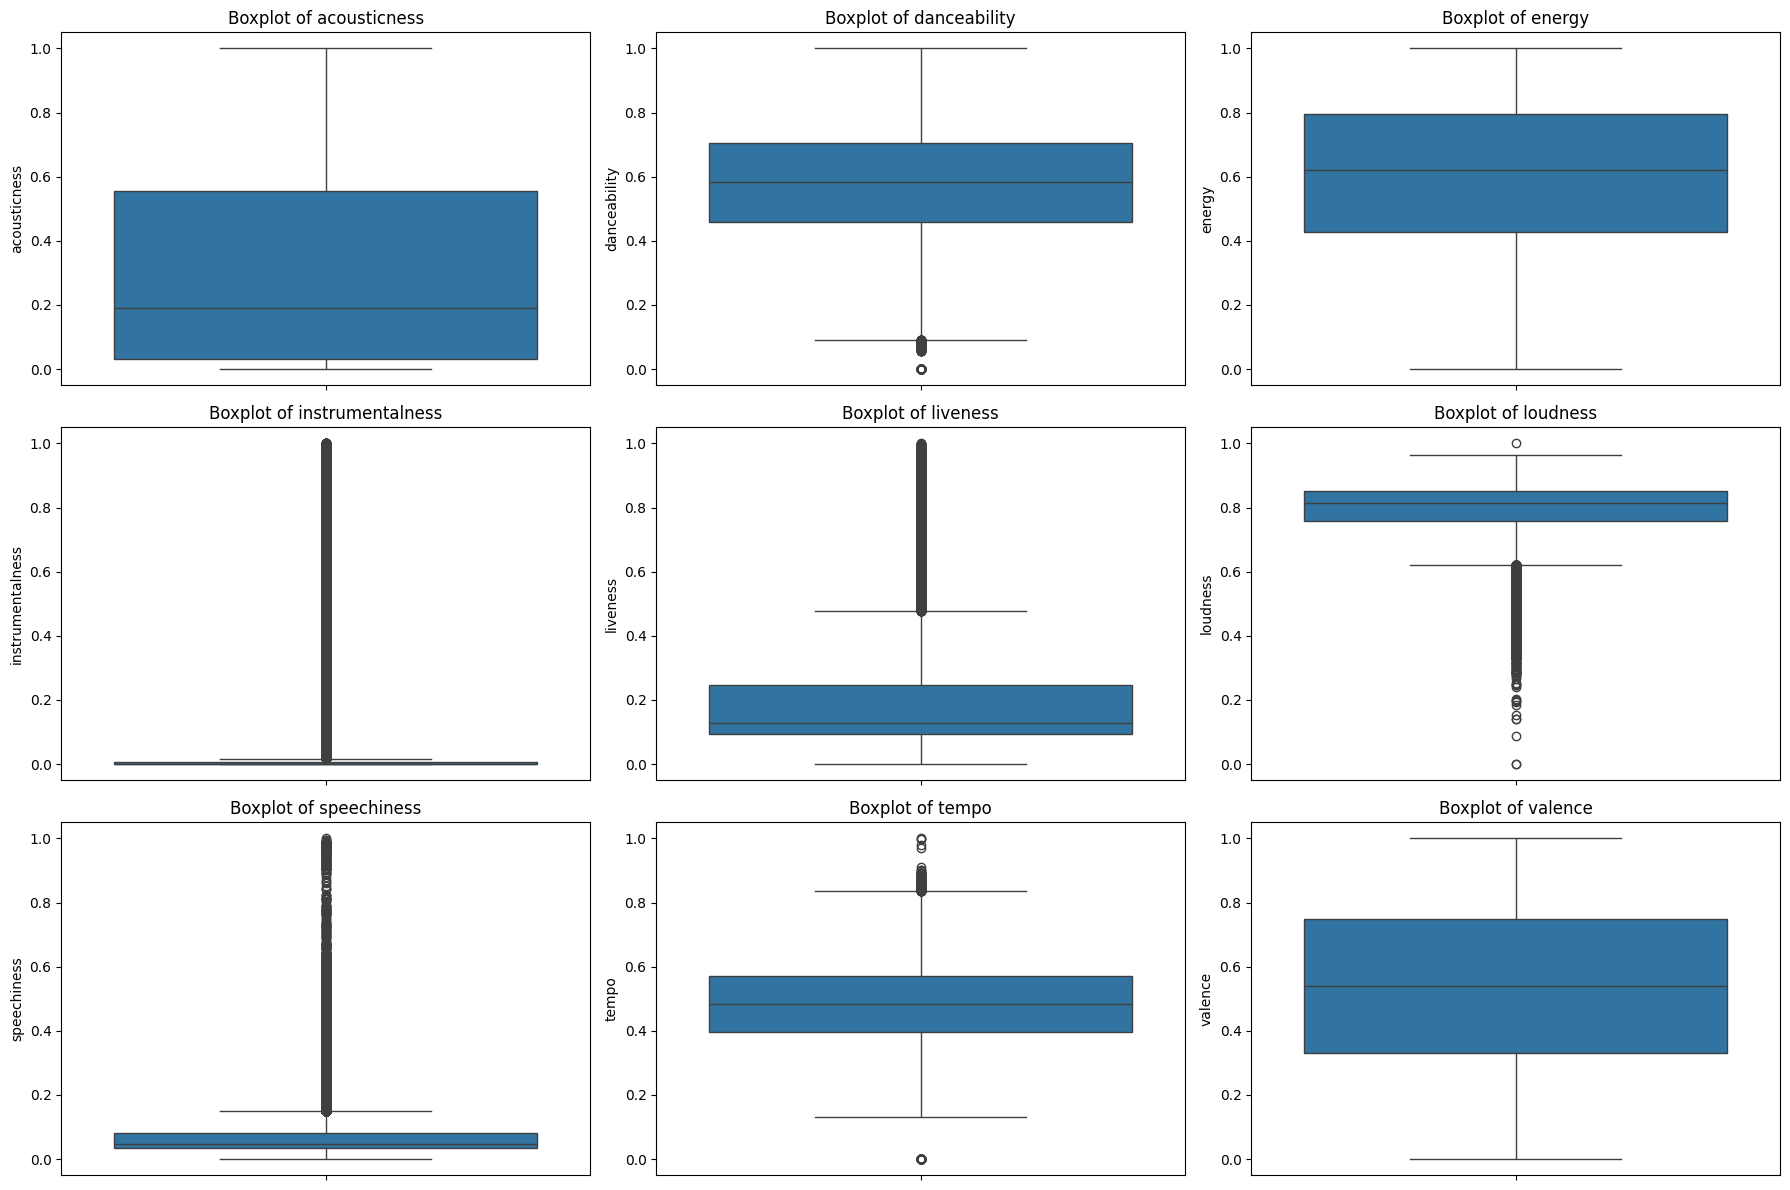

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
for i, feature in enumerate(audio_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=feature)
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

##  Feature Distribution (EDA)

Histograms with KDE allow us to observe the distribution shape, skewness, and frequency trends of features like popularity and audio metrics.

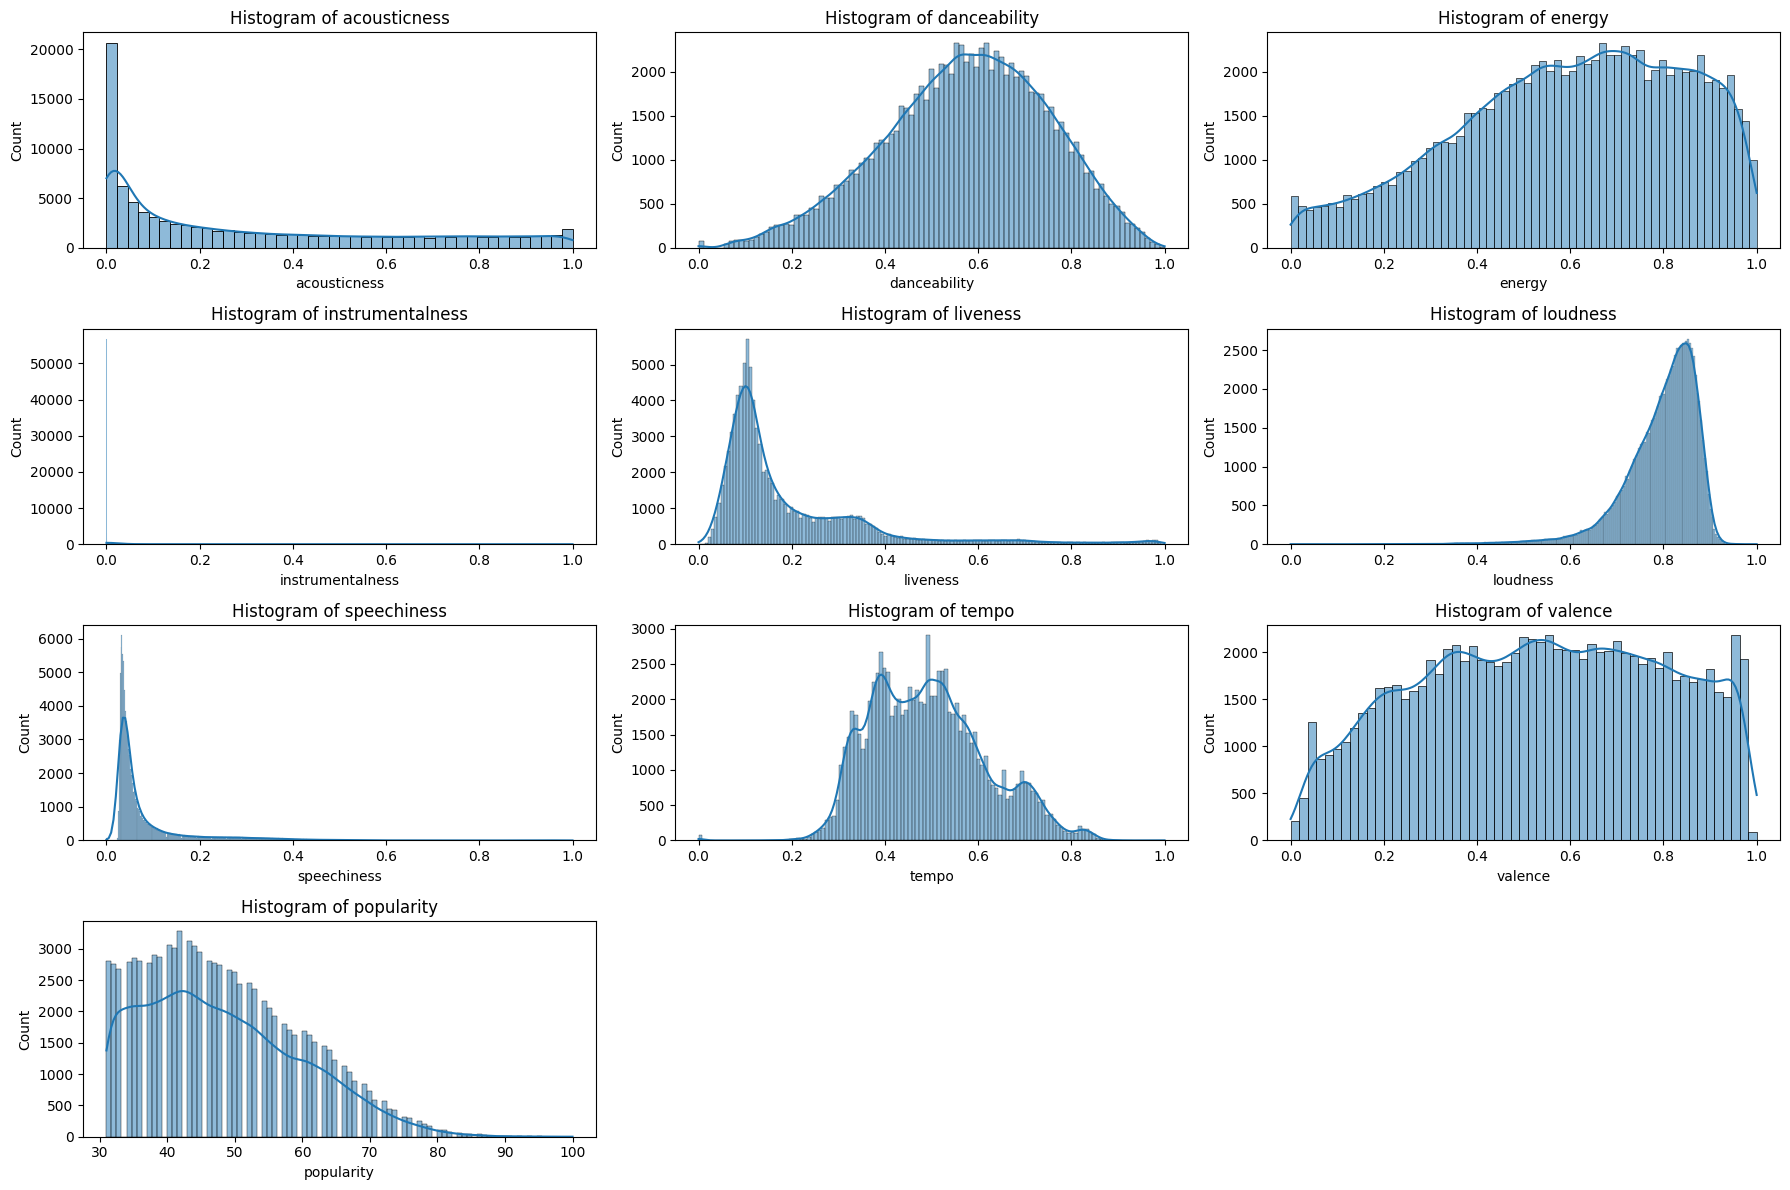

In [23]:
plt.figure(figsize=(18, 12))
for i, feature in enumerate(audio_features + ['popularity'], 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'Histogram of {feature}')
plt.tight_layout()
plt.show()

In [12]:
df[audio_features].describe()


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,93185.000000,93185.000000,93185.000000,93185.000000,93185.000000,93185.000000,93185.000000,93185.000000,93185.000000
mean,0.312045,0.574989,0.597241,0.093177,0.195283,0.795881,0.083280,0.492496,0.535146
std,0.314702,0.176101,0.242812,0.239766,0.169692,0.077555,0.094762,0.123758,0.257908
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.031325,0.458502,0.429000,0.000000,0.093100,0.758832,0.035172,0.395385,0.330000
50%,0.191767,0.584008,0.621000,0.000033,0.127000,0.812531,0.046306,0.484033,0.541000
75%,0.556225,0.703441,0.795000,0.006980,0.247000,0.850558,0.080957,0.571881,0.749000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


###  Cleaned Data Summary

- Removed duplicates: 
- Dropped missing values in key fields: 
- Converted and extracted `release_year` 
- Normalized audio features: 

The dataset is now ready for modeling in the next phase.
Save cleaned data for next notebook

## Save the Cleaned and Scaled Data

We save the processed data to a new CSV file for use in modeling or further analysis.

In [13]:
df.to_csv('cleaned_spotify_data.csv', index=False)
